In [1]:
import torch, os
os.environ["CUDA_VISIBLE_DEVICES"] = "4" 

In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW, get_linear_schedule_with_warmup
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, f1_score, accuracy_score, roc_curve, auc
from tqdm.auto import tqdm

# ==========================================
# 🛑 USER CONFIGURATION
# ==========================================
CONFIG = {
    # 1. 填入模型名稱 (BioBERT, BioClinicalBERT, PubMedBERT...)
    'model_name': 'emilyalsentzer/Bio_ClinicalBERT', 
    
    # 2. 儲存檔名
    'save_name': 'bioclinicalbert_10fold', 
    
    # --- 統一參數 ---
    'n_folds': 10,          # 10-Fold
    'seed': 42,             # 固定種子
    'max_length': 512,
    'batch_size': 16,       # 若 OOM 改 8
    'epochs': 4,            # 10-Fold 通常跑 3-4 epochs 就夠，避免跑太久
    'learning_rate': 2e-5,
    'data_path': 'final_mimic_dataset.csv',
    'target_column': 'los', 
    'text_column': 'text',  
    'threshold': 7.0
}

# ==========================================
# 核心函式庫 (CORE FUNCTIONS)
# ==========================================
def set_seed(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)

class ICUDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        encoding = self.tokenizer.encode_plus(
            text, add_special_tokens=True, max_length=self.max_len,
            return_token_type_ids=False, padding='max_length',
            truncation=True, return_attention_mask=True, return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler):
    model = model.train()
    losses, correct_predictions = [], 0
    for d in data_loader:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        targets = d["labels"].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, targets)
        
        preds = torch.argmax(outputs.logits, dim=1)
        correct_predictions += torch.sum(preds == targets)
        losses.append(loss.item())
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    return correct_predictions.double() / len(data_loader.dataset), np.mean(losses)

def eval_model(model, data_loader, loss_fn, device):
    model = model.eval()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_probs = []    # 新增: 儲存機率
    all_targets = []  # 新增: 儲存真實標籤
    
    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["labels"].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, targets)
            losses.append(loss.item())
            
            # 取出 Class 1 的機率 (Positive Probability)
            probs = torch.softmax(outputs.logits, dim=1)[:, 1]
            preds = torch.argmax(outputs.logits, dim=1)
            correct_predictions += torch.sum(preds == targets)
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
    metrics = {
        'accuracy': (correct_predictions.double() / len(data_loader.dataset)).item(),
        'loss': np.mean(losses),
        'auc': roc_auc_score(all_targets, all_probs),
        'f1': f1_score(all_targets, all_preds),
    }
    
    # 回傳 metrics 以及原始數據 (用於畫圖)
    return metrics, np.array(all_targets), np.array(all_probs)

def plot_cross_val_roc(history, model_name="Model"):
    plt.figure(figsize=(10, 8))
    
    # 計算平均 ROC
    mean_tpr = np.mean(history['tprs'], axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(history['mean_fpr'], mean_tpr)
    std_auc = np.std(history['aucs'])
    
    plt.plot(history['mean_fpr'], mean_tpr, color='b',
             label=r'Mean ROC (AUC = %0.3f $\pm$ %0.2f)' % (mean_auc, std_auc),
             lw=2, alpha=.8)

    # 畫出標準差陰影
    std_tpr = np.std(history['tprs'], axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
    plt.fill_between(history['mean_fpr'], tprs_lower, tprs_upper, color='grey', alpha=.2,
                     label=r'$\pm$ 1 std. dev.')

    # 對角線
    plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)

    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title(f'ROC Curve - {model_name}\n(10-Fold Cross-Validation)', fontsize=16)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    
    save_file = f"ROC_Curve_{model_name.split('/')[-1]}.png"
    plt.savefig(save_file, dpi=300, bbox_inches='tight')
    print(f"📊 圖表已儲存為: {save_file}")
    plt.show()
    

In [3]:
# ==========================================
# 主程式
# ==========================================
history = {
    'tprs': [],
    'aucs': [],
    'mean_fpr': np.linspace(0, 1, 100)
}

if __name__ == "__main__":
    set_seed(CONFIG['seed'])
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🚀 10-Fold CV + ROC  | Model: {CONFIG['model_name']}")
    
    # 1. 讀取資料
    if not os.path.exists(CONFIG['data_path']):
        raise FileNotFoundError(f"找不到 {CONFIG['data_path']}")
    df = pd.read_csv(CONFIG['data_path'])
    df['label'] = (df[CONFIG['target_column']] > CONFIG['threshold']).astype(int)
    df[CONFIG['text_column']] = df[CONFIG['text_column']].fillna("No Report")
    
    X = df[CONFIG['text_column']].to_numpy()
    y = df['label'].to_numpy()
    
    # 2. 初始化
    skf = StratifiedKFold(n_splits=CONFIG['n_folds'], shuffle=True, random_state=CONFIG['seed'])
    tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
    
    fold_results = []
    
    # 初始化畫圖數據容器
    history = {
        'tprs': [],
        'aucs': [],
        'mean_fpr': np.linspace(0, 1, 100)
    }
    
    # 3. 10-Fold 迴圈
    for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
        print(f"\n{'='*20} Fold {fold+1}/{CONFIG['n_folds']} {'='*20}")
        
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        train_ds = ICUDataset(X_train, y_train, tokenizer, CONFIG['max_length'])
        val_ds = ICUDataset(X_val, y_val, tokenizer, CONFIG['max_length'])
        
        train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'])
        
        model = AutoModelForSequenceClassification.from_pretrained(CONFIG['model_name'], num_labels=2)
        model = model.to(device)
        
        optimizer = AdamW(model.parameters(), lr=CONFIG['learning_rate'])
        total_steps = len(train_loader) * CONFIG['epochs']
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
        loss_fn = nn.CrossEntropyLoss().to(device)
        
        best_fold_f1 = 0
        best_metrics = {}
        # 暫存該 Fold 最佳的 ROC 數據
        best_fold_roc_data = None 
        
        for epoch in range(CONFIG['epochs']):
            train_acc, train_loss = train_epoch(model, train_loader, loss_fn, optimizer, device, scheduler)
            # 取得驗證指標與原始數據
            val_metrics, val_y_true, val_y_prob = eval_model(model, val_loader, loss_fn, device)
            
            print(f"  Ep {epoch+1}: Loss {train_loss:.3f} | Val F1 {val_metrics['f1']:.3f} | AUC {val_metrics['auc']:.3f}")
            
            if val_metrics['f1'] > best_fold_f1:
                best_fold_f1 = val_metrics['f1']
                best_metrics = val_metrics
                # 暫存最佳 Epoch 的預測結果，用於畫圖
                best_fold_roc_data = (val_y_true, val_y_prob)
        
        print(f"✅ Fold {fold+1} Best F1: {best_metrics['f1']:.4f}")
        fold_results.append(best_metrics)
        
        # --- [關鍵] 收集 ROC 數據 ---
        if best_fold_roc_data is not None:
            y_true, y_prob = best_fold_roc_data
            fpr, tpr, _ = roc_curve(y_true, y_prob)
            # 插值法對齊
            interp_tpr = np.interp(history['mean_fpr'], fpr, tpr)
            interp_tpr[0] = 0.0
            history['tprs'].append(interp_tpr)
            history['aucs'].append(best_metrics['auc'])
        
        del model, optimizer, scheduler
        torch.cuda.empty_cache()

    # 4. 總結與畫圖
    print(f"\n{'#'*30}\n🏆 Final Report\n{'#'*30}")
    metrics_df = pd.DataFrame(fold_results)
    print(metrics_df.describe().loc[['mean', 'std']])
    
    # 存檔
    metrics_df.to_csv(f"{CONFIG['save_name']}_metrics.csv", index=False)
    
    # 畫圖
    plot_cross_val_roc(history, model_name=CONFIG['model_name'])

🚀 10-Fold CV + ROC  | Model: emilyalsentzer/Bio_ClinicalBERT

==================== Fold 1/10 ====================


2025-12-01 14:56:49.525847: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-01 14:56:49.603612: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-01 14:56:51.308064: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Some weights of BertForSequenceClassification were not initialized from the mode

  Ep 1: Loss 0.689 | Val F1 0.316 | AUC 0.597
  Ep 2: Loss 0.673 | Val F1 0.197 | AUC 0.621
  Ep 3: Loss 0.649 | Val F1 0.625 | AUC 0.656
  Ep 4: Loss 0.606 | Val F1 0.523 | AUC 0.645
✅ Fold 1 Best F1: 0.6250

==================== Fold 2/10 ====================


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/joychou/anaconda3/envs/env-pytorch2/lib/python3.12/site-packages/transformers/optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


  Ep 1: Loss 0.689 | Val F1 0.291 | AUC 0.598
  Ep 2: Loss 0.663 | Val F1 0.626 | AUC 0.597
  Ep 3: Loss 0.624 | Val F1 0.519 | AUC 0.612
  Ep 4: Loss 0.556 | Val F1 0.532 | AUC 0.605
✅ Fold 2 Best F1: 0.6262

==================== Fold 3/10 ====================


...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/joychou/anaconda3/envs/env-pytorch2/lib/python3.12/site-packages/transformers/optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


  Ep 1: Loss 0.685 | Val F1 0.519 | AUC 0.580
  Ep 2: Loss 0.659 | Val F1 0.418 | AUC 0.579
  Ep 3: Loss 0.612 | Val F1 0.509 | AUC 0.570
  Ep 4: Loss 0.541 | Val F1 0.480 | AUC 0.573
✅ Fold 9 Best F1: 0.5195

==================== Fold 10/10 ====================


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/joychou/anaconda3/envs/env-pytorch2/lib/python3.12/site-packages/transformers/optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


  Ep 1: Loss 0.684 | Val F1 0.443 | AUC 0.582
  Ep 2: Loss 0.663 | Val F1 0.440 | AUC 0.621
  Ep 3: Loss 0.617 | Val F1 0.549 | AUC 0.622
  Ep 4: Loss 0.557 | Val F1 0.511 | AUC 0.629
✅ Fold 10 Best F1: 0.5495

##############################
🏆 Final Report
##############################
      accuracy      loss       auc        f1
mean  0.568364  0.684462  0.613074  0.581524
std   0.025246  0.033764  0.029891  0.042990


NameError: name 'plt' is not defined

🚀 啟動喚醒模式 (Loading Weights)... 使用 cuda
📦 測試集大小: 584 筆 (與訓練時一致)
🔄 載入 BioClinicalBERT 架構與權重...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 成功讀取訓練權重！


Predicting:   0%|          | 0/37 [00:00<?, ?it/s]


🏆 BioClinicalBERT 最終結果 (Test Set)
Accuracy : 0.5771
AUC-ROC  : 0.6111
F1 Score : 0.5550
----------------------------------------
              precision    recall  f1-score   support

           0       0.62      0.57      0.60       319
           1       0.53      0.58      0.55       265

    accuracy                           0.58       584
   macro avg       0.58      0.58      0.58       584
weighted avg       0.58      0.58      0.58       584

🔮 正在繪製 ROC 曲線...
✅ 圖表已儲存為: ROC_Curve_BioClinicalBERT_Final.png


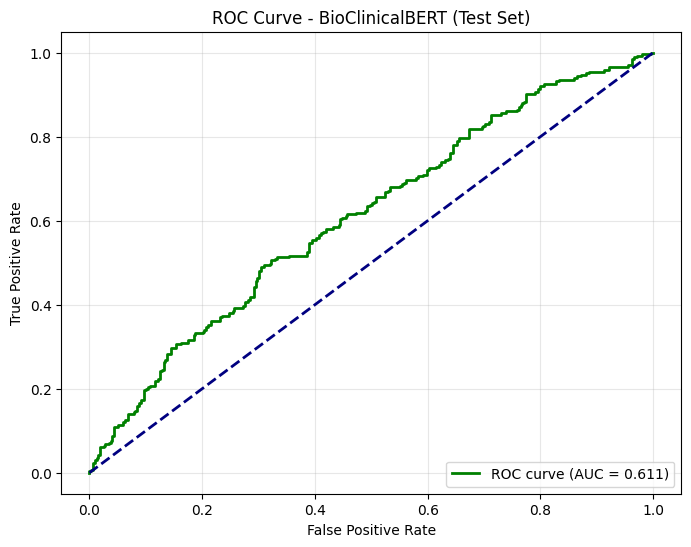

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt  # <--- 這就是你剛剛缺少的關鍵
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, classification_report, roc_auc_score, f1_score, accuracy_score
from tqdm.auto import tqdm

# ==========================================
# 1. 設定 (必須與訓練時完全一樣)
# ==========================================
CONFIG = {
    'model_name': 'emilyalsentzer/Bio_ClinicalBERT', 
    'model_path': 'best_bioclinicalbert_icu_model.bin', # 你的權重檔
    'data_path': 'final_mimic_dataset.csv',             # 你的資料檔
    'max_length': 512,
    'batch_size': 16,
    'seed': 42 # 【重要】種子必須一樣，切分出來的 Test Set 才會一樣
}

# ==========================================
# 2. 核心函式
# ==========================================
class ICUDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts; self.labels = labels; self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, item):
        text = str(self.texts[item]); label = self.labels[item]
        encoding = self.tokenizer.encode_plus(
            text, add_special_tokens=True, max_length=self.max_len,
            return_token_type_ids=False, padding='max_length',
            truncation=True, return_attention_mask=True, return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def get_predictions(model, data_loader, device):
    model = model.eval()
    all_probs = []; all_preds = []; all_targets = []
    
    with torch.no_grad():
        for d in tqdm(data_loader, desc="Predicting"):
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["labels"].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1)[:, 1] # Class 1 Probability
            preds = torch.argmax(logits, dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
    return np.array(all_targets), np.array(all_preds), np.array(all_probs)

# ==========================================
# 3. 主執行區 (喚醒模型)
# ==========================================
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🚀 啟動喚醒模式 (Loading Weights)... 使用 {device}")
    
    # A. 重現資料切分 (Re-create Split)
    # 這是為了確保我們用的是當初訓練時保留的那一份 "Test Set"
    df = pd.read_csv(CONFIG['data_path'])
    df['label'] = (df['los'] > 7.0).astype(int)
    df['text'] = df['text'].fillna("No Report")
    
    # 第一次切分 (Train / Temp)
    _, temp_df = train_test_split(df, test_size=0.2, random_state=CONFIG['seed'], stratify=df['label'])
    # 第二次切分 (Val / Test) - 我們要的是這個 Test
    _, test_df = train_test_split(temp_df, test_size=0.5, random_state=CONFIG['seed'], stratify=temp_df['label'])
    
    print(f"📦 測試集大小: {len(test_df)} 筆 (與訓練時一致)")
    
    # B. 載入模型架構與權重
    print(f"🔄 載入 BioClinicalBERT 架構與權重...")
    tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
    model = AutoModelForSequenceClassification.from_pretrained(CONFIG['model_name'], num_labels=2)
    
    # 【關鍵步驟】載入你訓練好的 .bin 檔案
    try:
        model.load_state_dict(torch.load(CONFIG['model_path']))
        print("✅ 成功讀取訓練權重！")
    except FileNotFoundError:
        print(f"❌ 找不到權重檔: {CONFIG['model_path']}，請確認檔名是否正確。")
        exit()
        
    model.to(device)
    
    # C. 進行預測
    test_dataset = ICUDataset(test_df.text.to_numpy(), test_df.label.to_numpy(), tokenizer, CONFIG['max_length'])
    test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'])
    
    y_true, y_pred, y_prob = get_predictions(model, test_loader, device)
    
    # D. 輸出報表
    print("\n" + "="*40)
    print(f"🏆 BioClinicalBERT 最終結果 (Test Set)")
    print("="*40)
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"AUC-ROC  : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred):.4f}")
    print("-" * 40)
    print(classification_report(y_true, y_pred))
    print("="*40)
    
    # E. 畫圖 (這次不會報錯了！)
    print("🔮 正在繪製 ROC 曲線...")
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - BioClinicalBERT (Test Set)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    save_file = "ROC_Curve_BioClinicalBERT_Final.png"
    plt.savefig(save_file, dpi=300)
    print(f"✅ 圖表已儲存為: {save_file}")
    plt.show()

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    average_precision_score,
    classification_report
)
from tqdm.auto import tqdm

# ==========================================
# 🛑 使用者設定 (BioClinicalBERT)
# ==========================================
CONFIG = {
    # 1. 模型名稱 (BioClinicalBERT)
    'model_name': 'emilyalsentzer/Bio_ClinicalBERT', 
    
    # 2. 權重檔名 (請確認你的檔案是用這個名字)
    # 你之前提到過你的存檔是這個名字
    'model_path': 'best_bioclinicalbert_icu_model.bin',  
    
    # 3. 其他參數
    'data_path': 'final_mimic_dataset.csv',
    'max_length': 512,
    'batch_size': 16,
    'seed': 42 
}

# ==========================================
# 核心函式
# ==========================================
class ICUDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts; self.labels = labels; self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, item):
        text = str(self.texts[item]); label = self.labels[item]
        encoding = self.tokenizer.encode_plus(
            text, add_special_tokens=True, max_length=self.max_len,
            return_token_type_ids=False, padding='max_length',
            truncation=True, return_attention_mask=True, return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def get_predictions(model, data_loader, device):
    model = model.eval()
    all_probs = []; all_preds = []; all_targets = []
    
    with torch.no_grad():
        for d in tqdm(data_loader, desc="Evaluating"):
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["labels"].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1)[:, 1] # Class 1 (Long Stay) Prob
            preds = torch.argmax(logits, dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
    return np.array(all_targets), np.array(all_preds), np.array(all_probs)

def calculate_detailed_metrics(y_true, y_pred, y_prob):
    # 混淆矩陣
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # 基礎指標
    acc = accuracy_score(y_true, y_pred)
    
    # Positive (Class 1)
    precision_pos = precision_score(y_true, y_pred, pos_label=1) # PPV
    recall_pos = recall_score(y_true, y_pred, pos_label=1)       # Sensitivity
    f1_pos = f1_score(y_true, y_pred, pos_label=1)
    
    # Negative (Class 0)
    precision_neg = precision_score(y_true, y_pred, pos_label=0) # NPV
    recall_neg = recall_score(y_true, y_pred, pos_label=0)       # Specificity
    f1_neg = f1_score(y_true, y_pred, pos_label=0)
    
    # Macro F1
    f1_macro = f1_score(y_true, y_pred, average='macro')
    
    # Advanced
    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    
    results = {
        'Accuracy (ACC)': acc,
        'Precision (PPV)': precision_pos,
        'Recall (Sensitivity)': recall_pos,
        'Specificity (SP)': recall_neg,
        'NPV': precision_neg,
        'F1 Score (Positive)': f1_pos,
        'F1 Score (Negative)': f1_neg,
        'F1 Score (Macro)': f1_macro,
        'AUROC': auroc,
        'AUPRC': auprc
    }
    
    return results, (tn, fp, fn, tp)

# ==========================================
# 主程式
# ==========================================
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🚀 啟動 BioClinicalBERT 全方位評估... 使用 {device}")
    
    # 1. 準備資料
    df = pd.read_csv(CONFIG['data_path'])
    df['label'] = (df['los'] > 7.0).astype(int)
    df['text'] = df['text'].fillna("No Report")
    
    # 切分 (Train/Val/Test)
    _, temp_df = train_test_split(df, test_size=0.2, random_state=CONFIG['seed'], stratify=df['label'])
    _, test_df = train_test_split(temp_df, test_size=0.5, random_state=CONFIG['seed'], stratify=temp_df['label'])
    
    print(f"📦 測試集大小: {len(test_df)} 筆")
    
    # 2. 載入模型
    print(f"🔄 載入模型: {CONFIG['model_name']} ...")
    tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
    model = AutoModelForSequenceClassification.from_pretrained(CONFIG['model_name'], num_labels=2)
    
    try:
        model.load_state_dict(torch.load(CONFIG['model_path']))
        print(f"✅ 成功讀取權重: {CONFIG['model_path']}")
    except FileNotFoundError:
        print(f"❌ 錯誤：找不到檔案 {CONFIG['model_path']}。請確認檔名是否正確！")
        exit()
        
    model.to(device)
    
    # 3. 預測
    test_ds = ICUDataset(test_df.text.to_numpy(), test_df.label.to_numpy(), tokenizer, CONFIG['max_length'])
    test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'])
    
    y_true, y_pred, y_prob = get_predictions(model, test_loader, device)
    
    # 4. 計算並列印
    metrics, cm = calculate_detailed_metrics(y_true, y_pred, y_prob)
    tn, fp, fn, tp = cm
    
    print("\n" + "="*50)
    print(f"🏆 BioClinicalBERT 完整評估報告")
    print("="*50)
    print(f"{'Metric':<25} | {'Value':<10}")
    print("-" * 40)
    for k, v in metrics.items():
        print(f"{k:<25} | {v:.4f}")
    print("-" * 40)
    print(f"Confusion Matrix:\n [TN={tn}  FP={fp}]")
    print(f" [FN={fn}  TP={tp}]")
    print("="*50)

🚀 啟動 BioClinicalBERT 全方位評估... 使用 cuda
📦 測試集大小: 584 筆
🔄 載入模型: emilyalsentzer/Bio_ClinicalBERT ...


2025-12-03 14:57:18.465354: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-03 14:57:18.748967: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-03 14:57:24.386778: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Some weights of BertForSequenceClassification were not initialized from the mode

✅ 成功讀取權重: best_bioclinicalbert_icu_model.bin


Evaluating:   0%|          | 0/37 [00:00<?, ?it/s]


🏆 BioClinicalBERT 完整評估報告
Metric                    | Value     
----------------------------------------
Accuracy (ACC)            | 0.5771
Precision (PPV)           | 0.5310
Recall (Sensitivity)      | 0.5811
Specificity (SP)          | 0.5737
NPV                       | 0.6224
F1 Score (Positive)       | 0.5550
F1 Score (Negative)       | 0.5971
F1 Score (Macro)          | 0.5760
AUROC                     | 0.6111
AUPRC                     | 0.5574
----------------------------------------
Confusion Matrix:
 [TN=183  FP=136]
 [FN=111  TP=154]
